# Assignment 2: NLP Analysis of News Articles Using the NYTimes API

Step 3: Load the Saved Dataset

In [ ]:
# Mounting the drive to load the data from drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

file_path = "/content/drive/MyDrive/datacenters_articles1.csv"

if os.path.exists(file_path):
  print("File exists.")
else:
  print("File does not exist.")

File exists.


In [ ]:
df = pd.read_csv(file_path)
df.sample(2)

,Article#,Date,Time,Headline,Abstract,Lead Paragraph,URL,Location
1,2,2025-12-07,10:00:27,A Mysterious Company Came to Town With a $165 ...,As wealthier areas are pushing back against hu...,NaN,https://www.nytimes.com/2025/12/07/business/bo...,By David Segal
15,18,2025-11-25,15:45:06,Market Volatility Underscores Epic Buildup of ...,Some experts see a dangerous combination of fa...,NaN,https://www.nytimes.com/2025/11/25/business/ec...,By Patricia Cohen


In [ ]:
#Check for missing values and duplicates
print("\nMissing Values per Column:")
print(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")
df = df.drop_duplicates()


Missing Values per Column:
Article#           0
Date               0
Time               0
Headline           0
Abstract           0
Lead Paragraph    51
URL                0
Location           0
dtype: int64

Duplicate Rows: 0


In [ ]:
# Create a copy of the dataframe
df_1 = df.copy()  # Copies the content of 'df' into a new dataframe called 'df_1'

# Print the first few rows of the copied dataframe to confirm successful duplication
df_1.sample(2)

# Ensuring that any changes made to df can still remain the same in df_1.

,Article#,Date,Time,Headline,Abstract,Lead Paragraph,URL,Location
8,10,2025-12-03,20:33:52,Anthropic’s Chief Executive Acknowledges Risks...,As he and his company pour tens of billions in...,NaN,https://www.nytimes.com/2025/12/03/business/de...,By Cade Metz
39,51,2025-11-19,00:07:43,Who Attended Trump’s Dinner for the Saudi Crow...,Here are some of the notable guests invited to...,NaN,https://www.nytimes.com/2025/11/18/us/politics...,By The New York Times


Step 4: EDA part

In [ ]:
#  Clean up the data for analysis
# 'Location' holds the author byline. Let's clean it up by removing "By "
df['Author'] = df['Location'].astype(str).str.replace('^By ', '', regex=True)

# Combine Headline and Abstract to create a single text corpus for analysis
df['Full_Text'] = df['Headline'].fillna('') + ". " + df['Abstract'].fillna('')

In [ ]:
df['word_count'] = df['Abstract'].apply(lambda x: len(str(x).split()))
df['sentence_count'] = df['Abstract'].apply(lambda x: str(x).count('.'))
df['char_count'] = df['Abstract'].apply(lambda x: len(str(x)))
df['avg_word_length'] = df['char_count'] / df['word_count']

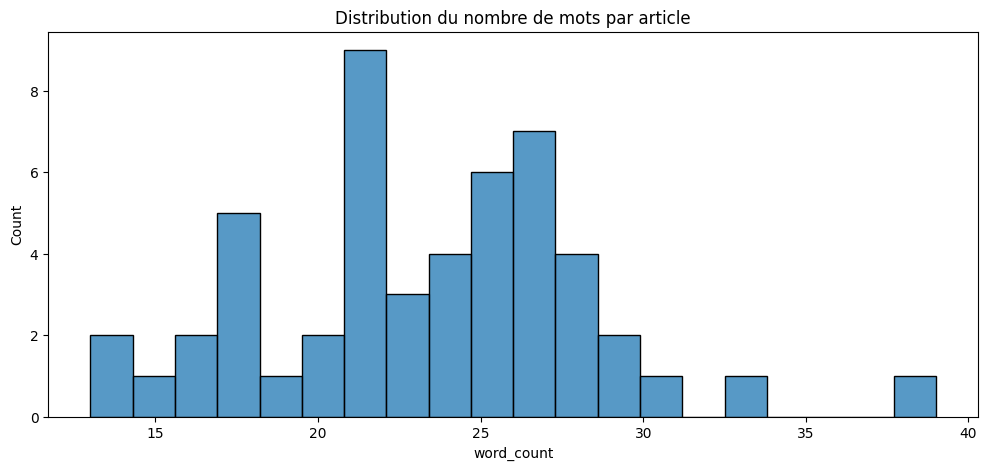

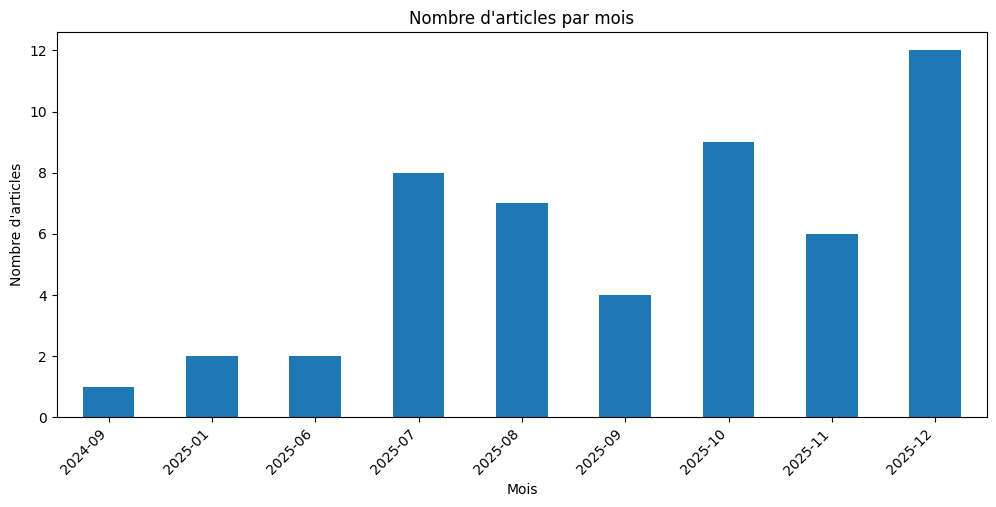

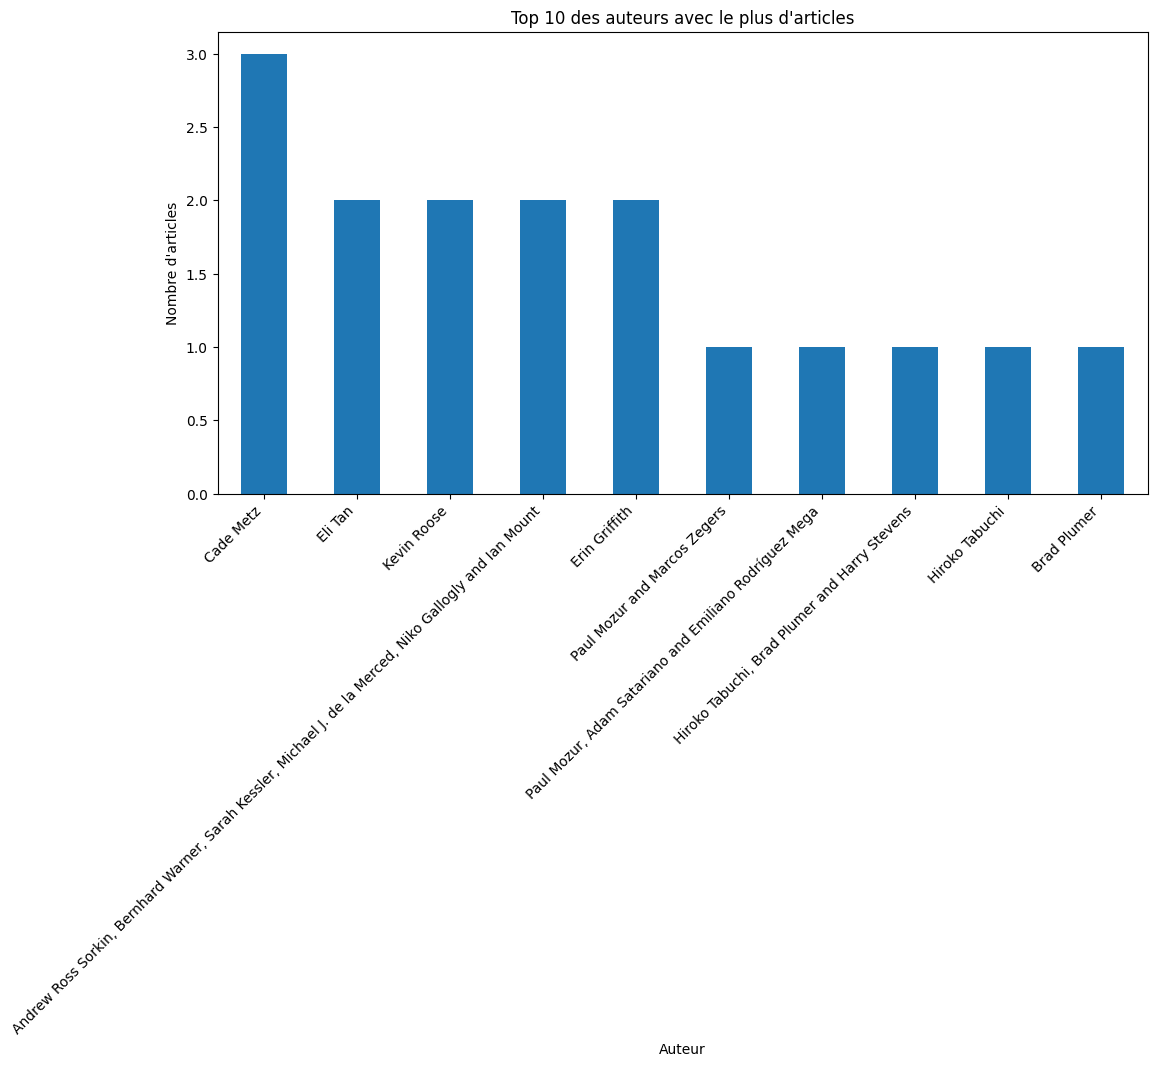

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.histplot(df['word_count'], bins=20)
plt.title("Distribution du nombre de mots par article")
plt.show()

# Assure-toi que la colonne Date est bien en datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Crée une colonne "Mois" pour le regroupement
df['Month'] = df['Date'].dt.to_period('M')  # format AAAA-MM

# Compte le nombre d'articles par mois
monthly_counts = df.groupby('Month')['Headline'].count()

# Affichage
plt.figure(figsize=(12,5))
monthly_counts.plot(kind='bar')
plt.title("Nombre d'articles par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45, ha='right')
plt.show()

author_counts = df['Author'].value_counts().head(10)  # Top 10 auteurs

# Affichage en bar chart
plt.figure(figsize=(12,6))
author_counts.plot(kind='bar')
plt.title("Top 10 des auteurs avec le plus d'articles")
plt.xlabel("Auteur")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df.sample(2)

,Article#,Date,Time,Headline,Abstract,Lead Paragraph,URL,Location,Author,Full_Text,word_count,sentence_count,char_count,avg_word_length,Month
28,34,2025-11-20,10:03:27,"To Meld A.I. With Supercomputers, National Lab...",A.I. has added urgency to the U.S. national la...,NaN,https://www.nytimes.com/2025/11/20/technology/...,By Don Clark,Don Clark,"To Meld A.I. With Supercomputers, National Lab...",28,5,173,6.178571,2025-11
50,69,2025-12-23,21:22:21,Looking Back at a Historic Year of Dismantling...,The Trump administration has aggressively pull...,NaN,https://www.nytimes.com/2025/12/23/climate/cli...,By David Gelles,David Gelles,Looking Back at a Historic Year of Dismantling...,21,1,159,7.571429,2025-12


Step 5: NLP Preprocessing Pipeline

In [ ]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Install gensim
!pip install gensim
from gensim.models import Word2Vec

# Text Cleaning and Tokenization
nlp = spacy.load("en_core_web_sm")

def clean_and_tokenize(text):
    doc = nlp(str(text).lower())

    clean_tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct and not token.is_space and not token.like_num and token.is_alpha:
            clean_tokens.append(token.lemma_)

    return clean_tokens

print("Applying text cleaning and tokenization. This might take a moment...")
# Apply the function to create a new column with the tokenized data
df['Cleaned_Tokens'] = df['Full_Text'].apply(clean_and_tokenize)

# Create a joined string version of the tokens for TF-IDF
df['Cleaned_Text'] = df['Cleaned_Tokens'].apply(lambda x: ' '.join(x))

print("\n--- Preprocessing Preview ---")
display(df[['Full_Text', 'Cleaned_Tokens']].head())


# 2. Vectorization

# --- A. TF-IDF Implementation ---
print("\nImplementing TF-IDF Vectorization...")
tfidf_vectorizer = TfidfVectorizer(max_features=1000) # Limiting to top 1000 words for performance
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Cleaned_Text'])

# Convert to DataFrame just to show the output structure (optional, but good for EDA)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")


# --- B. Word2Vec Implementation ---
print("\nImplementing Word2Vec Vectorization...")
tokenized_corpus = df['Cleaned_Tokens'].tolist()

# Train the Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_corpus, vector_size=10, window=5, min_count=2, workers=4)

print(f"Word2Vec Model trained. Vocabulary size: {len(w2v_model.wv)}")

# Example: Get the vector for a specific word if it exists in the vocabulary
sample_word = "center"
if sample_word in w2v_model.wv:
    print(f"\nVector for '{sample_word}':\n{w2v_model.wv[sample_word]}")
else:
    print(f"\nWord '{sample_word}' not found in vocabulary.")

Applying text cleaning and tokenization. This might take a moment...

--- Preprocessing Preview ---


,Full_Text,Cleaned_Tokens
0,Trump Plans to Give A.I. Developers a Free Han...,"[trump, plan, developer, free, hand, executive..."
1,A Mysterious Company Came to Town With a $165 ...,"[mysterious, company, come, town, idea, wealth..."
2,The A.I. Spending Frenzy Is Propping Up the Re...,"[spending, frenzy, prop, real, economy, trilli..."
3,The A.I. Boom Has Found Another Gear. Why Can’...,"[boom, find, gear, people, shake, worry, time,..."
4,How Chile Embodies A.I.’s No-Win Politics. Pol...,"[chile, embody, win, politic, political, debat..."



Implementing TF-IDF Vectorization...
TF-IDF Matrix Shape: (51, 565)

Implementing Word2Vec Vectorization...
Word2Vec Model trained. Vocabulary size: 170

Vector for 'center':
[-0.09553132  0.04904997 -0.08660949 -0.04313229 -0.00025206 -0.00220761
 -0.07368234  0.0974884   0.04801372  0.09166661]


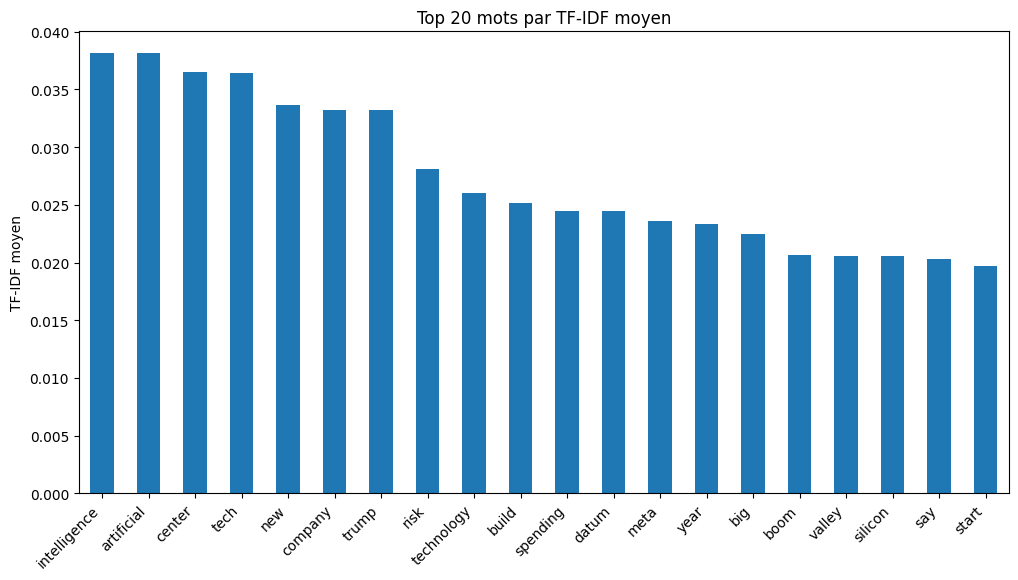

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculer la moyenne TF-IDF par mot
mean_tfidf = tfidf_df.mean().sort_values(ascending=False)

# Top 20 mots les plus importants
top_words = mean_tfidf.head(20)

# Visualisation
plt.figure(figsize=(12,6))
top_words.plot(kind='bar')
plt.title("Top 20 mots par TF-IDF moyen")
plt.ylabel("TF-IDF moyen")
plt.xticks(rotation=45, ha='right')
plt.show()

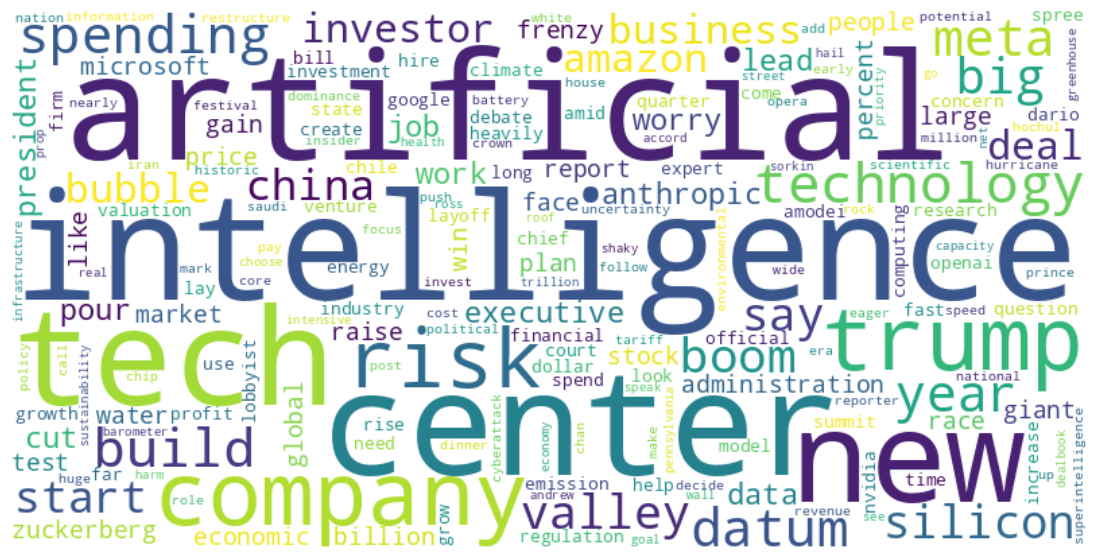

In [ ]:
from wordcloud import WordCloud

# Créer un dictionnaire {mot: score TF-IDF moyen}
tfidf_dict = mean_tfidf.to_dict()

# Générer le wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict)

# Affichage
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Initializing Sentiment Analyzers...

--- Sentiment Analysis Preview ---


,Full_Text,Vader_Label,TextBlob_Label,Afinn_Label
0,Trump Plans to Give A.I. Developers a Free Han...,Positive,Positive,Positive
1,A Mysterious Company Came to Town With a $165 ...,Positive,Positive,Positive
2,The A.I. Spending Frenzy Is Propping Up the Re...,Positive,Positive,Negative
3,The A.I. Boom Has Found Another Gear. Why Can’...,Negative,Positive,Negative
4,How Chile Embodies A.I.’s No-Win Politics. Pol...,Neutral,Negative,Negative



Plotting Sentiment Comparisons...


/tmp/ipykernel_155/3804431841.py:68: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_155/3804431841.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_155/3804431841.py:78: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




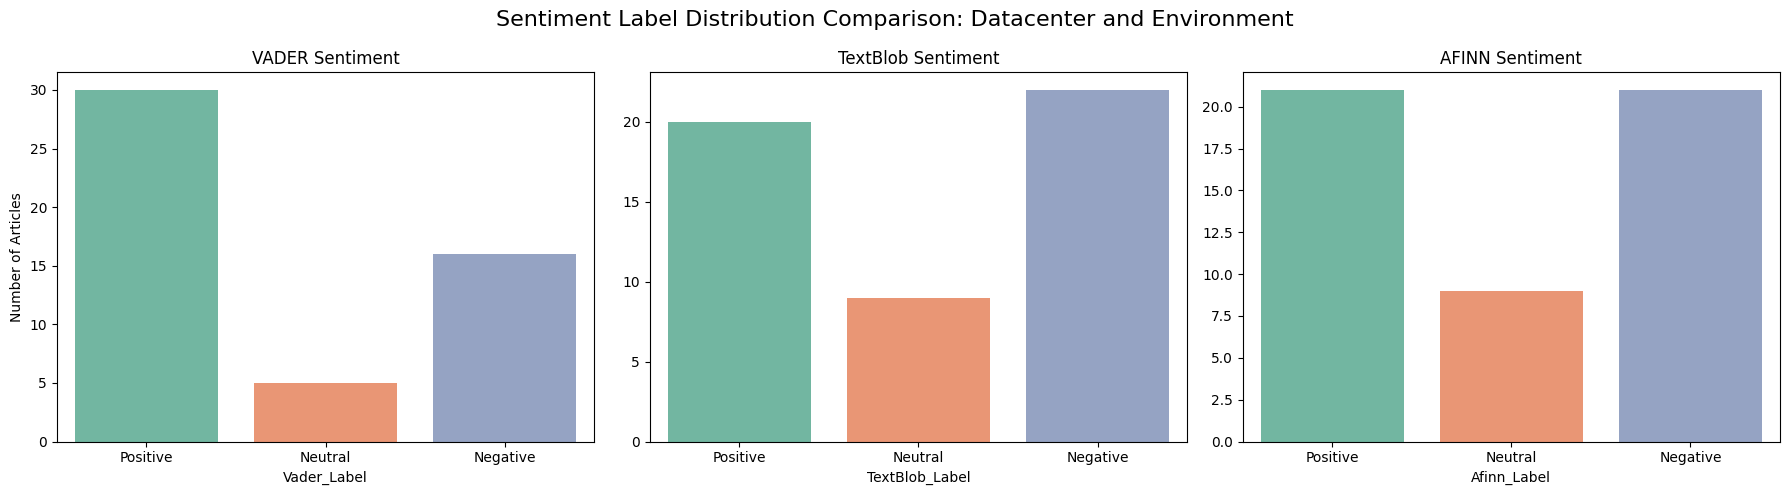

In [ ]:
# Install necessary libraries
!pip install vaderSentiment textblob afinn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from afinn import Afinn


print("Initializing Sentiment Analyzers...")
vader_analyzer = SentimentIntensityAnalyzer()
afinn_analyzer = Afinn()

# VADER Sentiment
def get_vader_sentiment(text):
    score = vader_analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return score, 'Positive'
    elif score <= -0.05:
        return score, 'Negative'
    else:
        return score, 'Neutral'

df[['Vader_Score', 'Vader_Label']] = df['Full_Text'].apply(
    lambda x: pd.Series(get_vader_sentiment(x))
)

# TextBlob Sentiment
def get_textblob_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0:
        return score, 'Positive'
    elif score < 0:
        return score, 'Negative'
    else:
        return score, 'Neutral'

df[['TextBlob_Score', 'TextBlob_Label']] = df['Full_Text'].apply(
    lambda x: pd.Series(get_textblob_sentiment(x))
)

# AFINN Sentiment
def get_afinn_sentiment(text):
    score = afinn_analyzer.score(str(text))
    if score > 0:
        return score, 'Positive'
    elif score < 0:
        return score, 'Negative'
    else:
        return score, 'Neutral'

df[['Afinn_Score', 'Afinn_Label']] = df['Full_Text'].apply(
    lambda x: pd.Series(get_afinn_sentiment(x))
)

print("\n--- Sentiment Analysis Preview ---")
display(df[['Full_Text', 'Vader_Label', 'TextBlob_Label', 'Afinn_Label']].head())


# Visualizing the Sentiment Distributions
print("\nPlotting Sentiment Comparisons...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sentiment Label Distribution Comparison: Datacenter and Environment', fontsize=16)

# VADER Plot
sns.countplot(data=df, x='Vader_Label', order=['Positive', 'Neutral', 'Negative'], ax=axes[0], palette='Set2')
axes[0].set_title('VADER Sentiment')
axes[0].set_ylabel('Number of Articles')

# TextBlob Plot
sns.countplot(data=df, x='TextBlob_Label', order=['Positive', 'Neutral', 'Negative'], ax=axes[1], palette='Set2')
axes[1].set_title('TextBlob Sentiment')
axes[1].set_ylabel('')

# AFINN Plot
sns.countplot(data=df, x='Afinn_Label', order=['Positive', 'Neutral', 'Negative'], ax=axes[2], palette='Set2')
axes[2].set_title('AFINN Sentiment')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

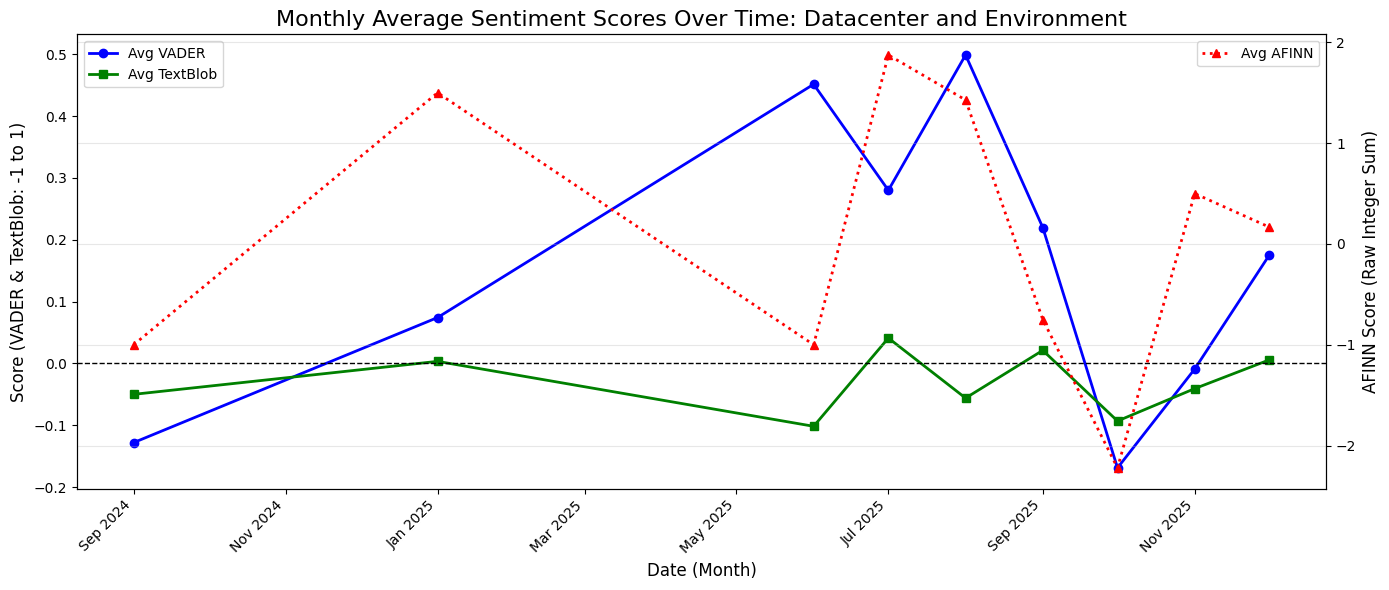

In [ ]:
import matplotlib.dates as mdates

# Ensure Date column is datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Create a Year-Month column for grouping (if not already created in Step 4)
df['YearMonth'] = df['Date'].dt.to_period('M')

# Average Sentiment Scores Over Time
monthly_sentiment = df.groupby('YearMonth')[['Vader_Score', 'TextBlob_Score', 'Afinn_Score']].mean()

# Convert the PeriodIndex back to Datetime for smooth plotting
monthly_sentiment.index = monthly_sentiment.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot VADER and TextBlob on the primary y-axis
ax1.plot(monthly_sentiment.index, monthly_sentiment['Vader_Score'], marker='o', label='Avg VADER', color='blue', linewidth=2)
ax1.plot(monthly_sentiment.index, monthly_sentiment['TextBlob_Score'], marker='s', label='Avg TextBlob', color='green', linewidth=2)

ax1.set_xlabel('Date (Month)', fontsize=12)
ax1.set_ylabel('Score (VADER & TextBlob: -1 to 1)', fontsize=12)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.legend(loc='upper left')

# Plot AFINN on a secondary y-axis because its scale is different
ax2 = ax1.twinx()
ax2.plot(monthly_sentiment.index, monthly_sentiment['Afinn_Score'], marker='^', label='Avg AFINN', color='red', linewidth=2, linestyle=':')
ax2.set_ylabel('AFINN Score (Raw Integer Sum)', fontsize=12)
ax2.legend(loc='upper right')

plt.title('Monthly Average Sentiment Scores Over Time: Datacenter and Environment', fontsize=16)

# Format the x-axis dates nicely
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Step 7: Sentiment Classification Model

Dataset shape after filtering out Neutral text: (46, 25)
Class distribution:
 Target
1    30
0    16
Name: count, dtype: int64

Training XGBoost Classifier

 Model Evaluation 

Confusion Matrix:
[[2 3]
 [0 5]]

Classification Report:
              precision    recall  f1-score   support

Negative (0)       1.00      0.40      0.57         5
Positive (1)       0.62      1.00      0.77         5

    accuracy                           0.70        10
   macro avg       0.81      0.70      0.67        10
weighted avg       0.81      0.70      0.67        10



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[01:38:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




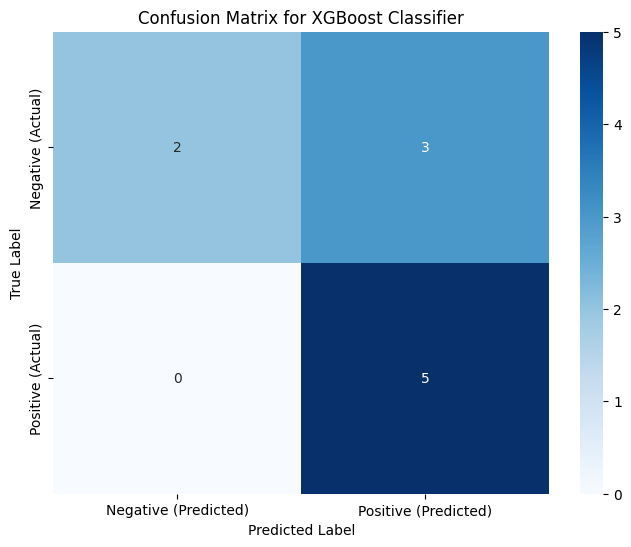


Saving models to disk...


['xgb_classifier_datacenter.pkl']

In [ ]:
!pip install xgboost

import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import seaborn as sns


# Create the Target Variable
df_model = df[df['Vader_Label'] != 'Neutral'].copy()
df_model['Target'] = df_model['Vader_Label'].map({'Positive': 1, 'Negative': 0})

print(f"Dataset shape after filtering out Neutral text: {df_model.shape}")
print("Class distribution:\n", df_model['Target'].value_counts())

# Convert Documents to Vectors
def get_document_vector(tokens, model, vector_size=10):
    valid_tokens = [word for word in tokens if word in model.wv]

    if not valid_tokens:
        return np.zeros(vector_size)

    return np.mean(model.wv[valid_tokens], axis=0)

X = np.array([get_document_vector(tokens, w2v_model, 10) for tokens in df_model['Cleaned_Tokens']])
y = df_model['Target'].values

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the XGBoost Model
print("\nTraining XGBoost Classifier")
xgb_classifier = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_classifier.fit(X_train, y_train)

# Model Evaluation
print("\n Model Evaluation ")
y_pred = xgb_classifier.predict(X_test)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
# Assuming 0 is Negative and 1 is Positive based on our mapping
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (Predicted)', 'Positive (Predicted)'],
            yticklabels=['Negative (Actual)', 'Positive (Actual)'])
plt.title('Confusion Matrix for XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Save the models
print("\nSaving models to disk...")
w2v_model.save("custom_w2v_datacenter.model")
joblib.dump(xgb_classifier, "xgb_classifier_datacenter.pkl")

In [ ]:
# Load the models back into memory
print("Loading models from disk...")
loaded_w2v = Word2Vec.load("custom_w2v_datacenter.model")
loaded_xgb = joblib.load("xgb_classifier_datacenter.pkl")

def predict_custom_text(text):
    tokens = clean_and_tokenize(text)

    vec = get_document_vector(tokens, loaded_w2v, vector_size=10)

    vec = vec.reshape(1, -1)

    # Predict
    prediction = loaded_xgb.predict(vec)[0]
    label = "Positive" if prediction == 1 else "Negative"

    return label, prediction

Loading models from disk...


In [ ]:
print("INTERACTIVE SENTIMENT PREDICTOR")
print("Type a sentence to evaluate its sentiment based on the trained model.")
print("Type 'exit' to quit the loop.\n")

# Interactive loop for keyboard input
while True:
    user_input = input("Enter sample text: ")

    if user_input.strip().lower() == 'exit':
        print("Exiting interactive predictor.")
        break

    if user_input.strip() == "":
        continue

    pred_label, pred_value = predict_custom_text(user_input)
    print(f"Predicted Sentiment: {pred_label} ({pred_value})\n")

INTERACTIVE SENTIMENT PREDICTOR
Type a sentence to evaluate its sentiment based on the trained model.
Type 'exit' to quit the loop.

Enter sample text: Datacenters are making a lot of money and are good!
Predicted Sentiment: Positive (1)

Enter sample text: exit
Exiting interactive predictor.
